In [3]:
import sys

sys.path.append("../src/")

import matplotlib.pyplot as plt
import torch
from imagegenerator import ImageGenerator
from pdb2mrc import PDB2MRC
from plotting_tools import *
import rotations
from tqdm import tqdm
import mrcfile
from filters import apply_bfactor, chimera_gaussian_sigma_to_bfactor, butter
import h5py

%load_ext autoreload
%autoreload 2

In [21]:
fft2 = lambda array: torch.fft.fftshift(torch.fft.fft2(torch.fft.ifftshift(array)))
ifft2 = lambda array: torch.fft.fftshift(torch.fft.ifft2(torch.fft.ifftshift(array)))

## Create 3D scattering potential

In [4]:
# fetch pdb file
pdb_code = "6bdf"
pm = PDB2MRC(pdb_code)
pm.fetch_pdb(pdb_folder="../pdb-data/")

../pdb-data/6bdf
PDB file saved to: ../pdb-data/6bdf.cif


/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 45654.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 45675.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 45706.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 45727.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain E is discontinuous at line 45758.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/c

In [5]:
# Samples 3D scattering potential onto specified grid
n = 256 # number of pixels per axis
dx = 1. # angstrom, pixel size.
pm.build_particle(n=n, dx=dx)
V = pm.particle.detach().clone()

100%|█████████████████████████████████████████████| 4/4 [00:02<00:00,  1.50it/s]


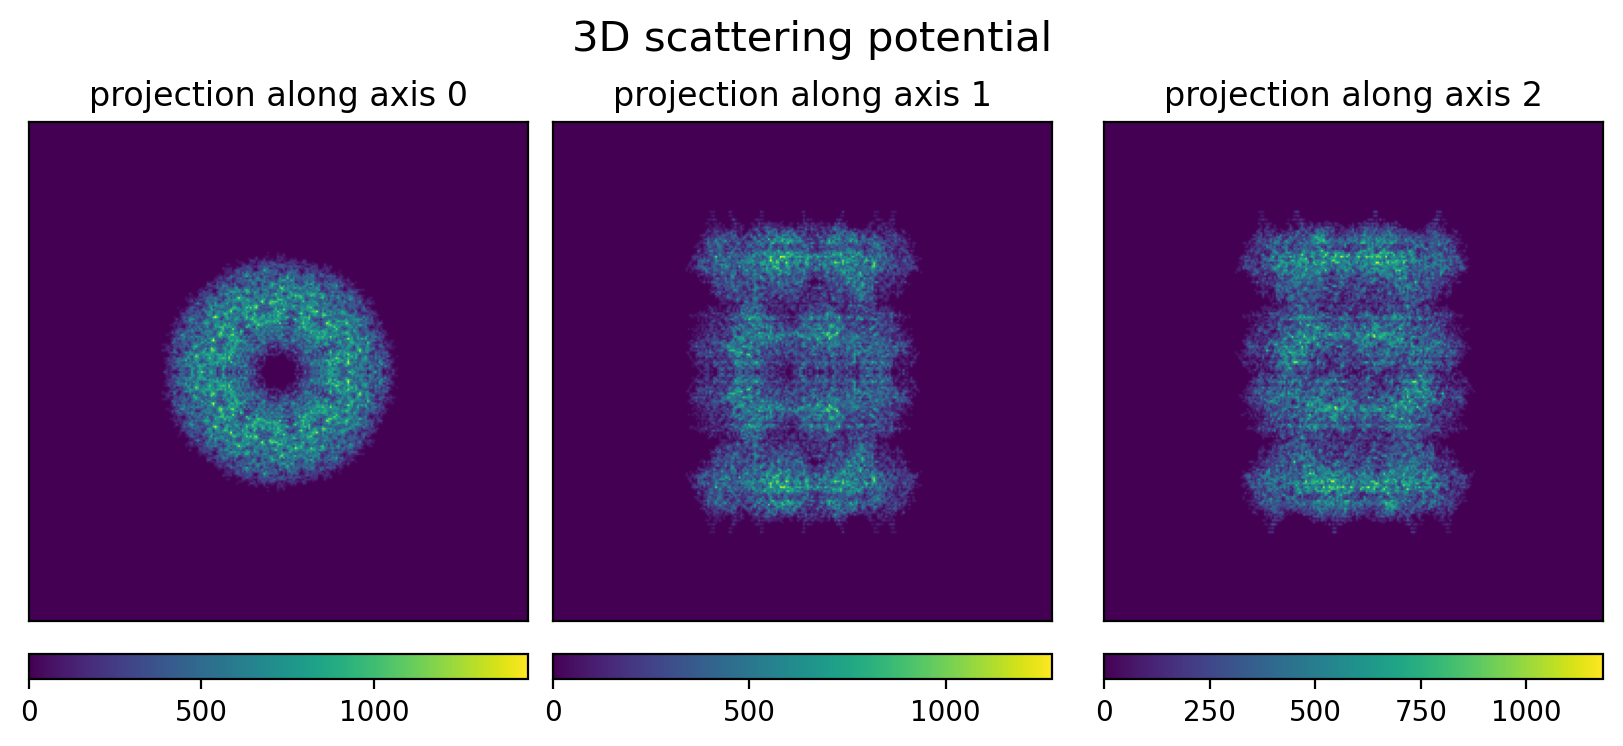

In [6]:
plot3d(V, title="3D scattering potential")

In [ ]:
# with mrcfile.open("/scratch/loh/joel/empiar-12391/8s7j_448x448x448_I1.mrc") as mrc:
#     V = torch.tensor(mrc.data)
# V.shape

In [ ]:
# with mrcfile.open('/scratch/loh/joel/thermofisher/adrian_aav9_new.mrc') as mrc:
#     V = torch.as_tensor(mrc.data.copy())
# V.shape

In [ ]:
# with mrcfile.new("/scratch/loh/joel/empiar-12391/8s7j_448x448x448_I1.mrc",
#     overwrite=True,
# ) as mrc:
#     mrc.set_data(V.cpu().numpy())
#     mrc.voxel_size = dx

## Manual rotation of 3D scattering potential (if you want)
Only if you want to pre-rotate the 3D potential before simulating images.

Use-case: maybe you want to simulate in-plane rotations of a different view of the particle.

In [ ]:
# y-plane rotation for e.g.
# rotation_angle = torch.tensor(torch.pi / 2)
# rotation_quaternion = torch.tensor(
#     [0, torch.sin(rotation_angle / 2), 0, torch.cos(rotation_angle / 2)]
# )
# rotation_matrix = rotations.quaternion_to_rotation_matrix(rotation_quaternion[None,...])
# affine_matrix = rotations.build_affine_matrix(rotation_matrix, torch.zeros(1,3))
# rotated_V = rotations.rotate_volume(V, affine_matrix)

In [ ]:
# plot3d(rotated_V.squeeze(), title="rotated V")

## Generate dataset
Here, you can choose to either use random or in-plane rotations, and random or fixed defocus values (comment/uncomment respectively).

In [ ]:
# chimera_gaussian_sigma_to_bfactor(0.8)

In [7]:
bfactor = 50
filtered = apply_bfactor(V, dx, bfactor)

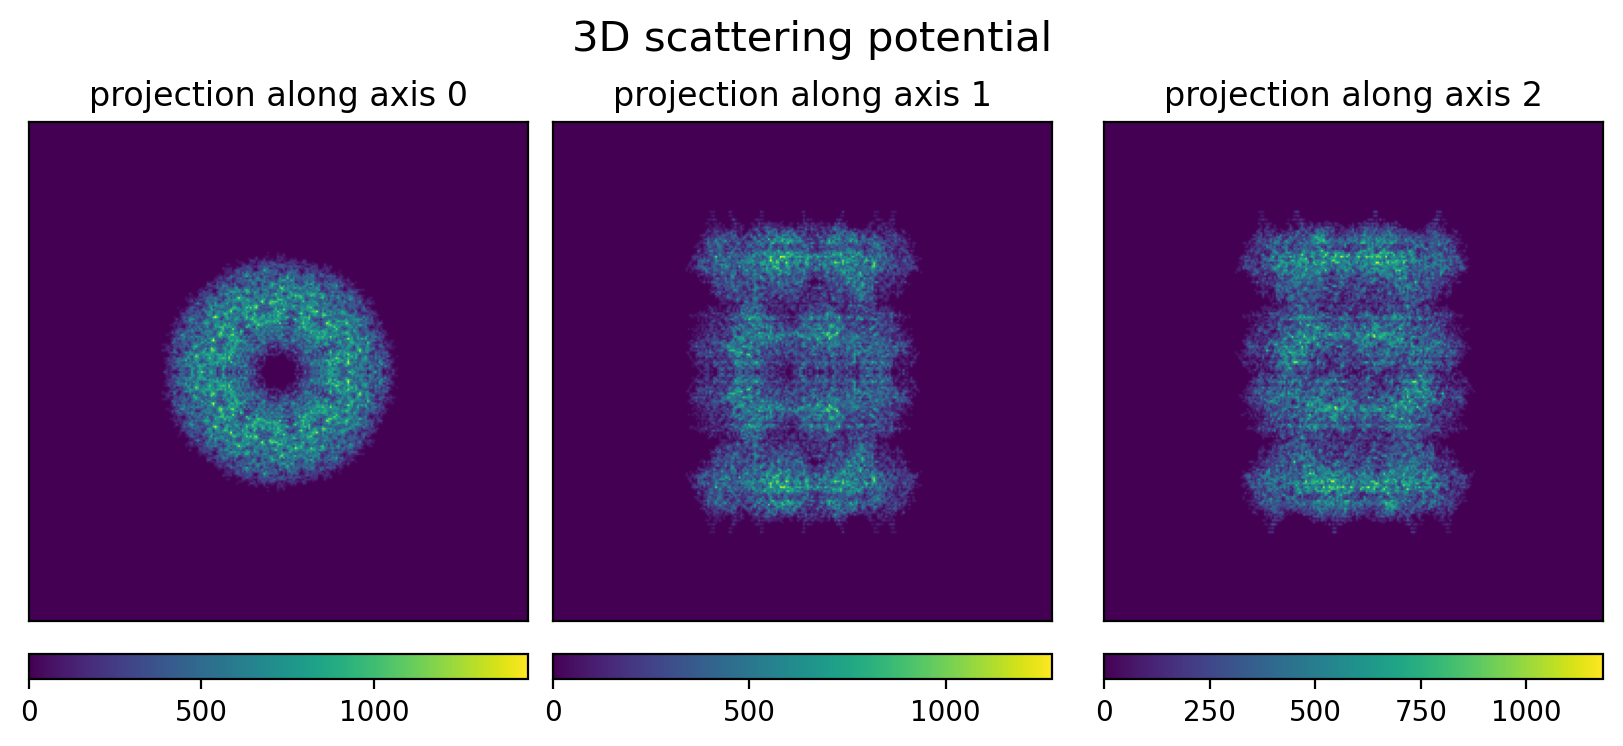

In [8]:
plot3d(V, title="3D scattering potential")

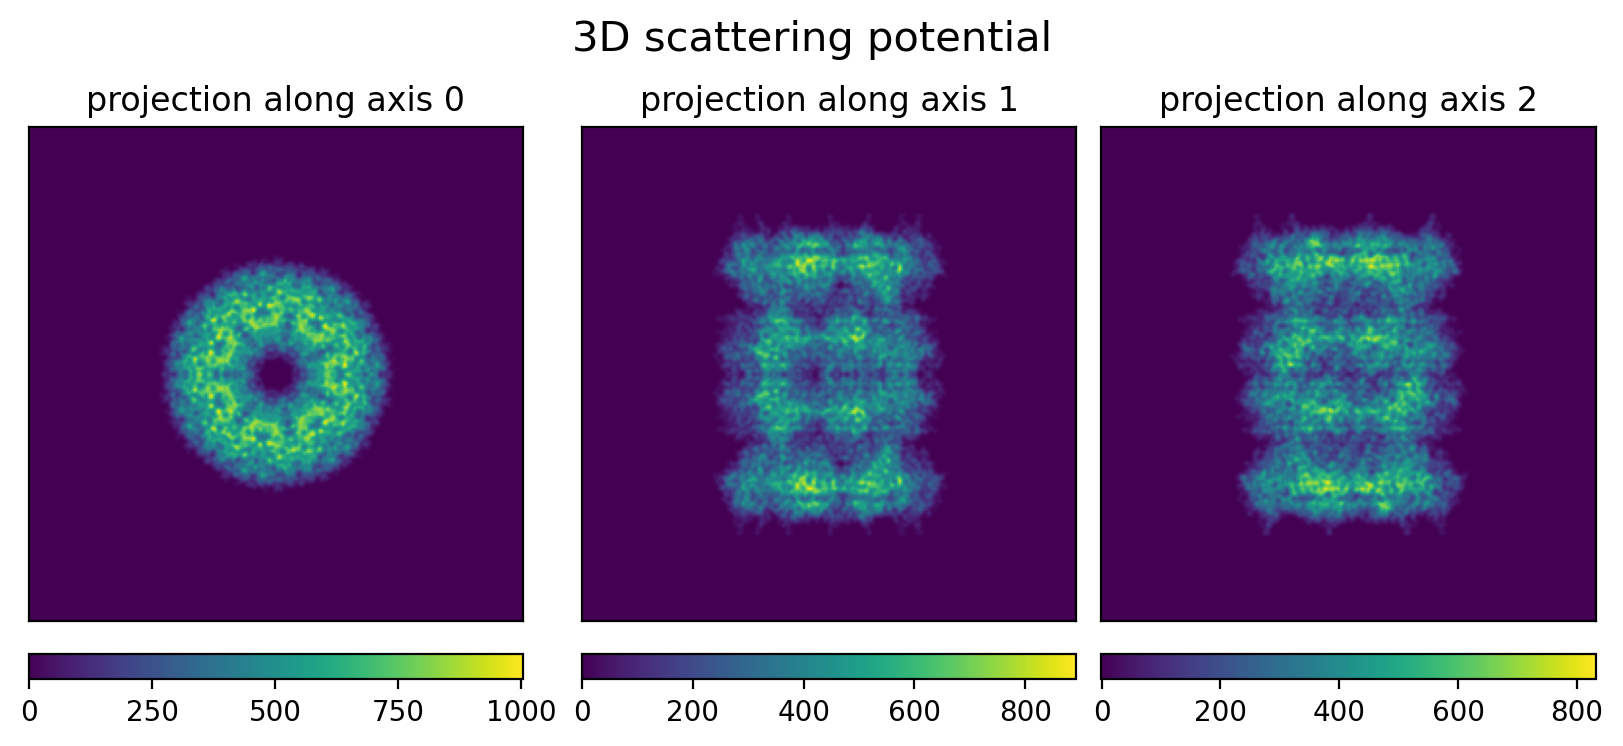

In [9]:
plot3d(filtered, title="3D scattering potential")

In [10]:
n_particles = 3000
energy = 100  # keV
dose_per_angstrom = 40  # e-/A^2
Cs = 1.5857857e7  # angstrom. Sherical aberration, typical values are 1-3 mm.
alpha = 0.1

In [11]:
# random quaternions
quaternions = torch.stack([rotations.random_quaternion() for i in range(n_particles)])

# in-plane rotations (around z-axis)
# angles = torch.linspace(0, 360, n_particles + 1)
# angles = angles[:-1] / 180 * torch.pi
# quaternions = []
# for a in angles:
#     # (x,y,z,w)
#     quaternions.append(torch.tensor([0, 0, torch.sin(a / 2), torch.cos(a / 2)]))
# quaternions = torch.stack(quaternions)

quaternions.shape

torch.Size([3000, 4])

In [12]:
# random defocus
defocus_min = 5000  # angstrom
defocus_max = 25000  # angstrom
dfang = 0
defocus_A = torch.rand(n_particles) * (defocus_max - defocus_min) + defocus_min

# fixed defocus
# defocus_A = 10000 * torch.ones(n_particles)

# beamtilt
tiltx = 0.
tilty = 0.

phaseshift = 0.

ctf_params = torch.stack(
    [torch.tensor([Cs, d, d, dfang, tiltx, tilty, phaseshift]) for d in defocus_A]
)
ctf_params.shape

torch.Size([3000, 7])

In [13]:
# random shift. set to 0 for no shifts
shift = 0.  # A
rlnOriginXAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
rlnOriginYAngst = 2 * (torch.rand(n_particles) - 0.5) * shift
translations = torch.stack([rlnOriginXAngst, rlnOriginYAngst], dim=-1)
translations.shape

torch.Size([3000, 2])

In [29]:
device = "cuda:1" #choose cpu if you run out of cuda memory.

In [30]:
# Use multislice, holography, poisson and random_choice to obtain close to experimental conditions.
scattering_model = "multislice"  # 'multislice', 'firstborn', 'projection', 'ctf'
aberration_model = "holography"  # 'holography' or 'ctf'
noise_model = None  # 'poisson' or None
ice_model = None  # 'randomchoice' or None
ice_thickness = 0 # angstroms
model = ImageGenerator(
    # V,  # or rotated_V
    filtered,  # or rotated_V
    dx,
    quaternions,
    translations,
    ctf_params,
    energy,
    dose_per_angstrom,
    ice_model=ice_model,
    ice_thickness=ice_thickness,
    scattering_model=scattering_model,
    aberration_model=aberration_model,
    noise_model=noise_model,
    klim=None,
    flip_curvature=False,
    alpha=alpha,
).to(device)

In [31]:
idx = torch.arange(n_particles) #new
images = []
batchsize = 5 # set higher or lower for faster/slower generation.
with torch.no_grad():
    for i in tqdm(range(0, n_particles, batchsize)):
        image = model(idx[i : i + batchsize])
        images.append(image.detach().cpu())

images = torch.concat(images, dim=0)
images.shape

100%|█████████████████████████████████████████| 600/600 [00:55<00:00, 10.89it/s]


torch.Size([3000, 256, 256])

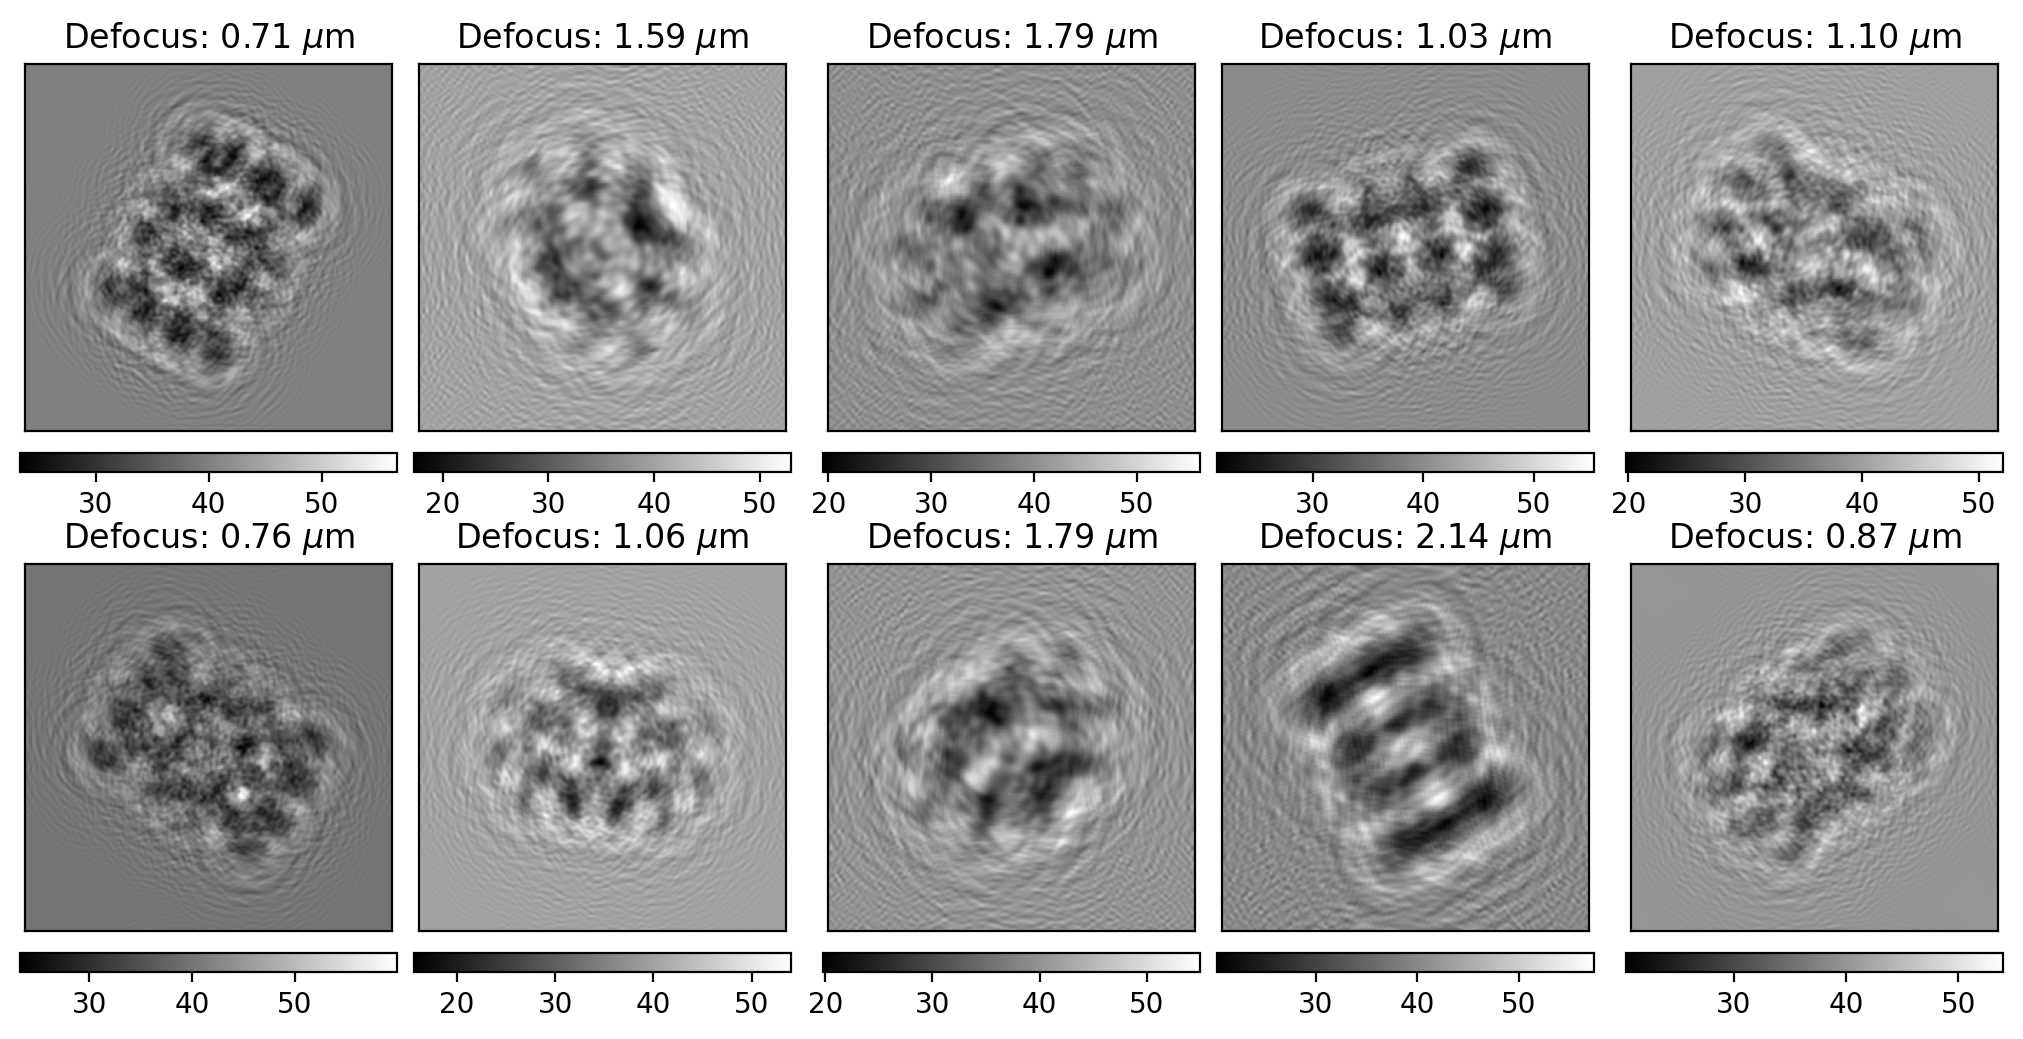

In [32]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow((images[i]), cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

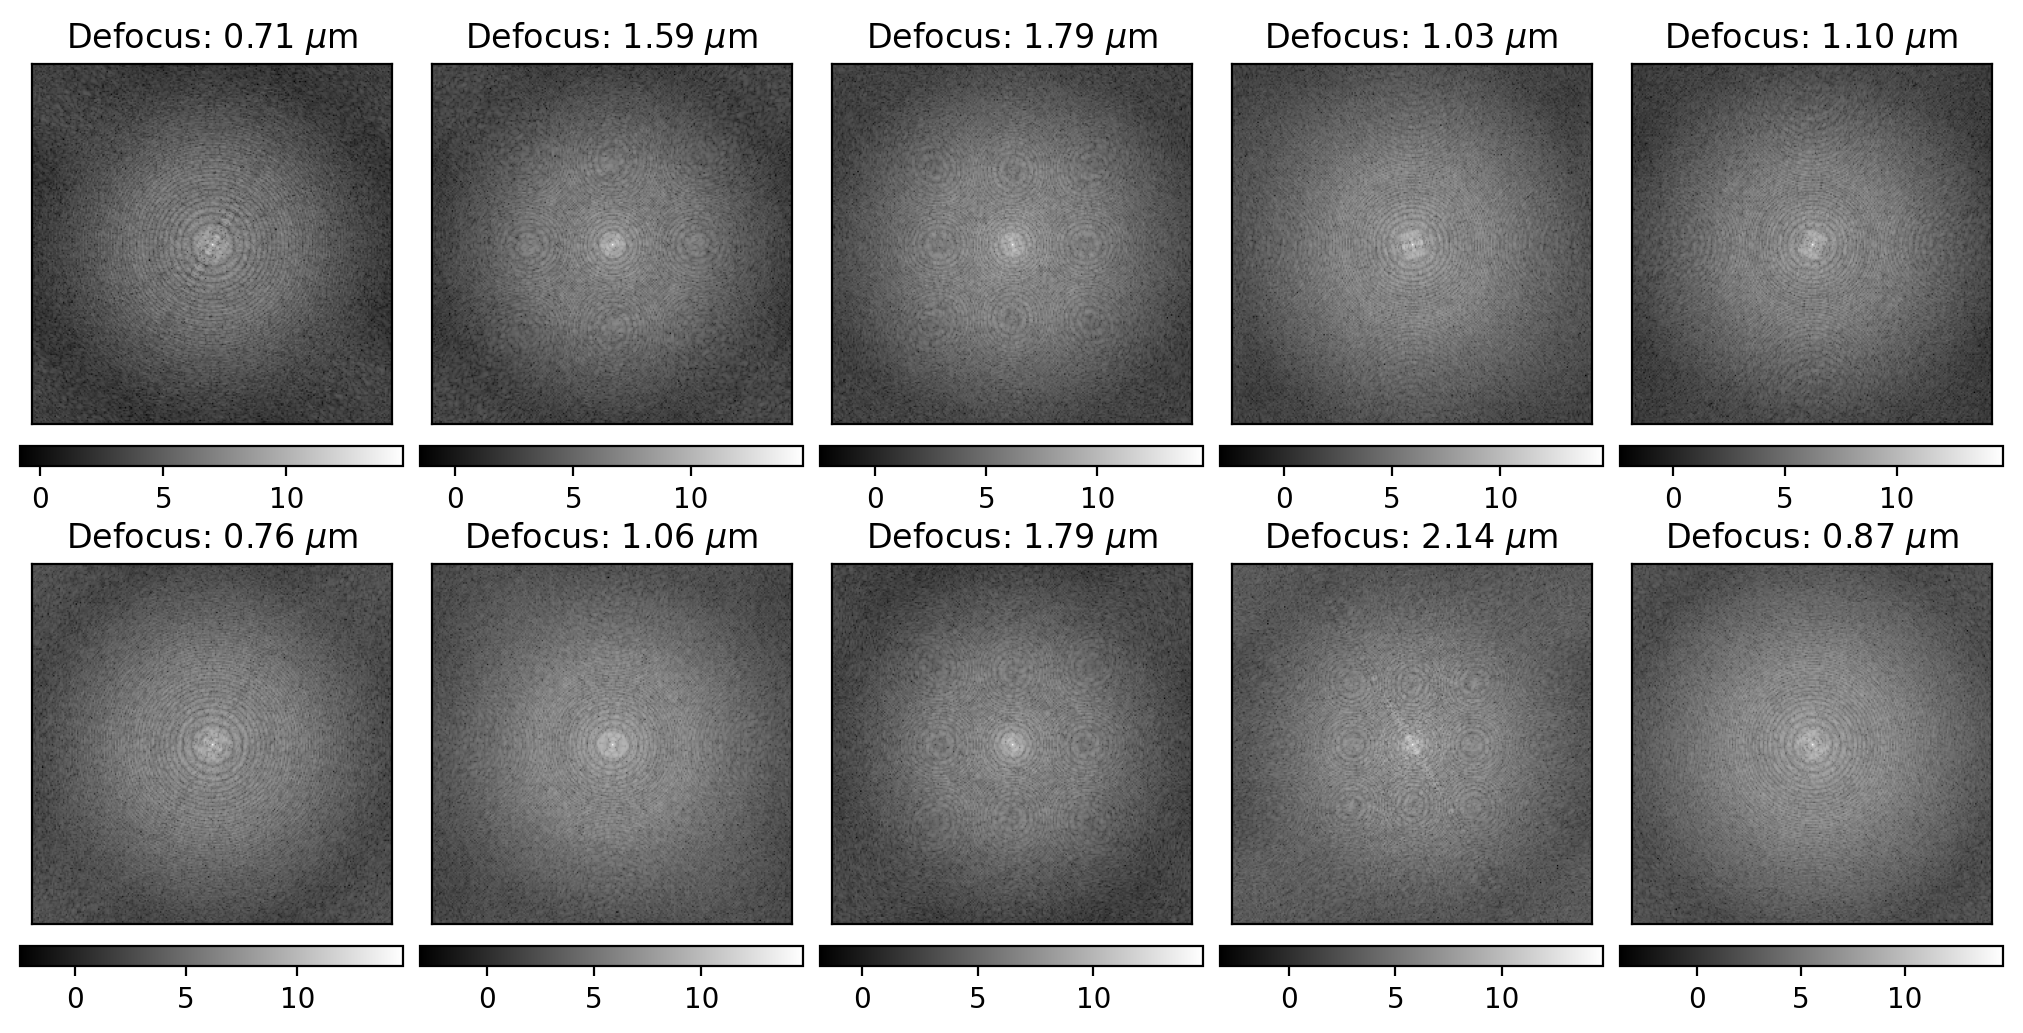

In [33]:
fig, axes = plt.subplots(2, 5, dpi=200, constrained_layout=True, figsize=(10, 5))
for i, ax in enumerate(axes.ravel()):
    im = ax.imshow(torch.log(torch.abs(fft2(images[i]))), cmap="grey")
    ax.set(xticks=[], yticks=[])
    ax.set_title(f"Defocus: {ctf_params[i,2]/10000:.2f} $\mu$m")
    fig.colorbar(im, ax=ax, location="bottom")
plt.show()

In [34]:
filename = f"/scratch/loh/joel/cryosparc-troubleshoot/T20S_check_cryosim_3D_reconstruction_29apr2025.h5"

In [35]:
with h5py.File(filename, "w") as f:
    f["data/intensities"] = images.detach().cpu().numpy()
    f["data/defocus_A"] = defocus_A
    f["data/orientations"] = quaternions.detach().cpu().numpy()
    f["data/rlnOriginYAngst"] = rlnOriginYAngst
    f["data/rlnOriginXAngst"] = rlnOriginXAngst
    f["params/alpha"] = alpha
    f["params/energy"] = energy
    f["params/cs"] = Cs
    f["params/roi"] = (n,n)
    f["params/dx"] = dx
    f["params/dose_per_angstrom"] = dose_per_angstrom
    f["params/bfactor"] = bfactor